In [ ]:
# Bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.model_selection import StratifiedKFold
from scipy.stats.mstats import winsorize

plt.style.use("ggplot")


In [25]:
radiomic = pd.read_csv("radiomic_data_binary.csv", encoding='latin1', sep=None, engine='python')

In [ ]:
#essas sao as variaveis de texto que vamos remover pois se traram dados que nao influenciam
valores_texto = [
    'diagnostics_Versions_PyRadiomics', 
    'diagnostics_Versions_Numpy',
    'diagnostics_Versions_SimpleITK',
    'diagnostics_Versions_PyWavelet', 
    'diagnostics_Versions_Python', 
    'diagnostics_Image-original_Hash', 
    'diagnostics_Mask-original_Hash', 
    'diagnostics_Configuration_Settings', 
    'diagnostics_Configuration_EnabledImageTypes', 
'diagnostics_Image-original_Dimensionality', 
    'diagnostics_Image-original_Spacing', 
    'diagnostics_Image-original_Size', 'diagnostics_Mask-original_Spacing', 
    'diagnostics_Mask-original_Size', 
    'diagnostics_Mask-original_BoundingBox', 
    'diagnostics_Mask-original_CenterOfMassIndex', 
    'diagnostics_Mask-original_CenterOfMass'
]

radiomic = radiomic.drop(valores_texto, axis=1)

In [27]:
dupes=radiomic.duplicated()
sum(dupes)

0

In [28]:
#remoção dos duplicados se houver
radiomic_ok = radiomic.drop_duplicates(keep='first')
#Identifica registros duplicados nos dados
dupes=radiomic_ok.duplicated()
sum(dupes)

0

In [47]:
#elimina as linhas com dados ausentes
radiomic = radiomic.dropna(how='any')

In [48]:
from sklearn.utils import resample

x = radiomic.drop("class", axis=1)
y = radiomic["class"]

# Juntando X e y para facilitar o balanceamento
df = pd.concat([x, y], axis=1)

# Separar as classes
print("Distribuição original das classes:")
print(y.value_counts())

# São duas classes chamadas 'BENIGN' e 'MALIGNANT'
df_majority = df[df['class'] == 'BENIGN']  
df_minority = df[df['class'] == 'MALIGNANT'] 

# Fazer undersampling da classe maior
df_majority_downsampled = resample(df_majority,
                                   replace=False,    # não faz repetição
                                   n_samples=len(df_minority),  # mesma quantidade da classe menor
                                   random_state=42) 

# Juntar as duas classes agora balanceadas
df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # embaralhar

# Separar de volta x e y
x = df_balanced.drop('class', axis=1)
y = df_balanced['class']

print("\nDistribuição após balanceamento:")
print(y.value_counts())

Distribuição original das classes:
class
BENIGN       1100
MALIGNANT     918
Name: count, dtype: int64

Distribuição após balanceamento:
class
BENIGN       918
MALIGNANT    918
Name: count, dtype: int64


Escolhi essas outras features para testar nesse outra questão, enquanto tentava entender rodei algumas funcoes que me mostram essas features com relevancia para os dados.

In [ ]:

features = ['original_firstorder_Median', 'original_glcm_Imc2', 
            'original_firstorder_RootMeanSquared', 'original_firstorder_Entropy']

In [51]:
x = x[features]

Tratamento de outliers usando winsorize que pareceu simples e eficaz de melhorar o codigo

In [52]:
def treat_outliers(data, threshold=0.05):
    data_clean = data.copy()
    for col in data.columns:
        data_clean[col] = winsorize(data[col], limits=[threshold, threshold])
    return data_clean

x_clean = treat_outliers(x)

In [53]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_clean)

 Determinar valor ideal de K usando o método do cotovelo

In [54]:
inertias = []
range_k = range(1, 11)

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inertias.append(kmeans.inertia_)

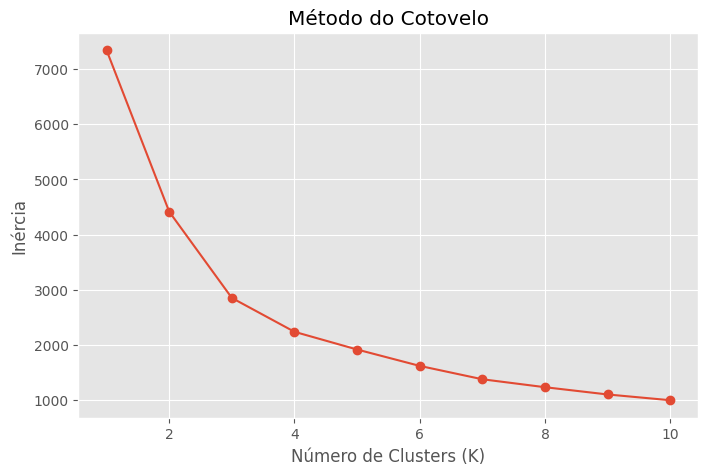

In [ ]:
# Plot do método do cotovelo

plt.figure(figsize=(8, 5))
plt.plot(range_k, inertias, marker='o')
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inércia")
plt.grid(True)
plt.show()

In [ ]:
# Escolhi K=3 porque é onde começa a estabilizar a curva
optimal_k = 3

# K-means com K ótimo
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(x_scaled)

In [ ]:
# clustering Hierárquico com dois métodos de linkage
methods = ['ward', 'complete']
hierarchical_labels = {}

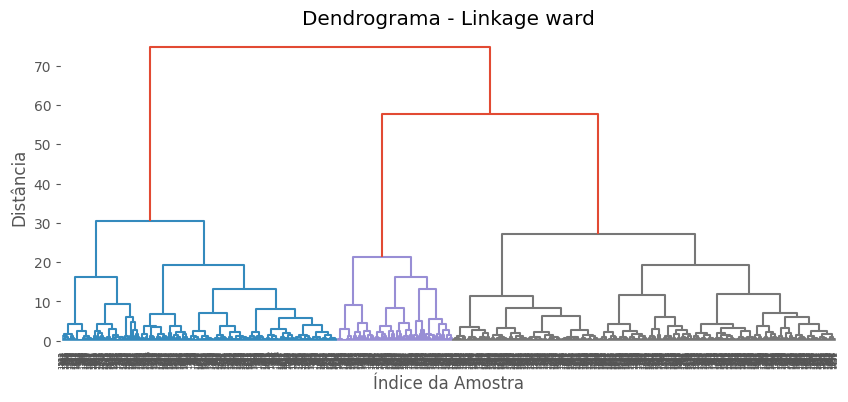

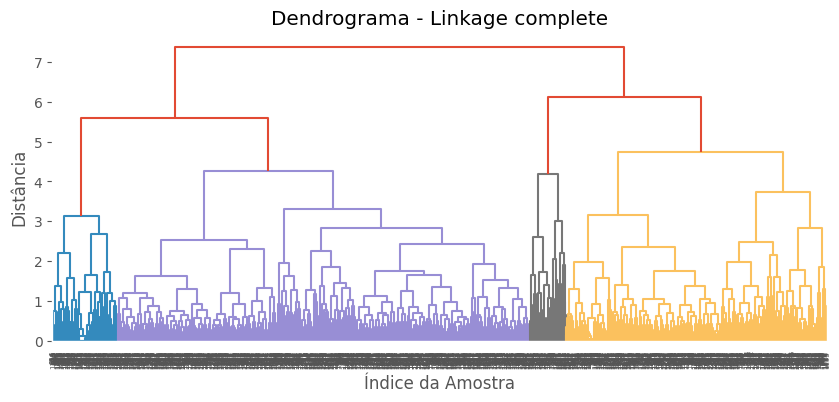

In [58]:
for method in methods:
    # linkage='ward' só aceita affinity='euclidean', que é default
    model = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    labels = model.fit_predict(x_scaled)
    hierarchical_labels[method] = labels

    # Plotando o dendrograma (só pra ver o formato dos agrupamentos)
    plt.figure(figsize=(10, 4))
    plt.title(f"Dendrograma - Linkage {method}")
    dendrogram(linkage(x_scaled, method=method))
    plt.xlabel("Índice da Amostra")
    plt.ylabel("Distância")
    plt.show()

In [59]:
print("\n--- Avaliação dos clusters ---")
print("K-means:")
print(f"Silhouette Score: {silhouette_score(x_scaled, kmeans_labels):.3f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(x_scaled, kmeans_labels):.3f}")


--- Avaliação dos clusters ---
K-means:
Silhouette Score: 0.401
Calinski-Harabasz Score: 1445.398


In [ ]:

for method in methods:
    print(f"\nHierárquico ({method}):")
    print(f"Silhouette Score: {silhouette_score(x_scaled, hierarchical_labels[method]):.3f}")
    print(f"Calinski-Harabasz Score: {calinski_harabasz_score(x_scaled, hierarchical_labels[method]):.3f}")
# Silhouette mede o quão "coeso" e "separado" os clusters estão. Quanto maior, melhor.
# Calinski-Harabasz mede a dispersão entre os clusters vs dentro dos clusters. Também: quanto maior, melhor.



Hierárquico (ward):
Silhouette Score: 0.396
Calinski-Harabasz Score: 1409.581

Hierárquico (complete):
Silhouette Score: 0.353
Calinski-Harabasz Score: 865.646


In [ ]:


pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(x_scaled)

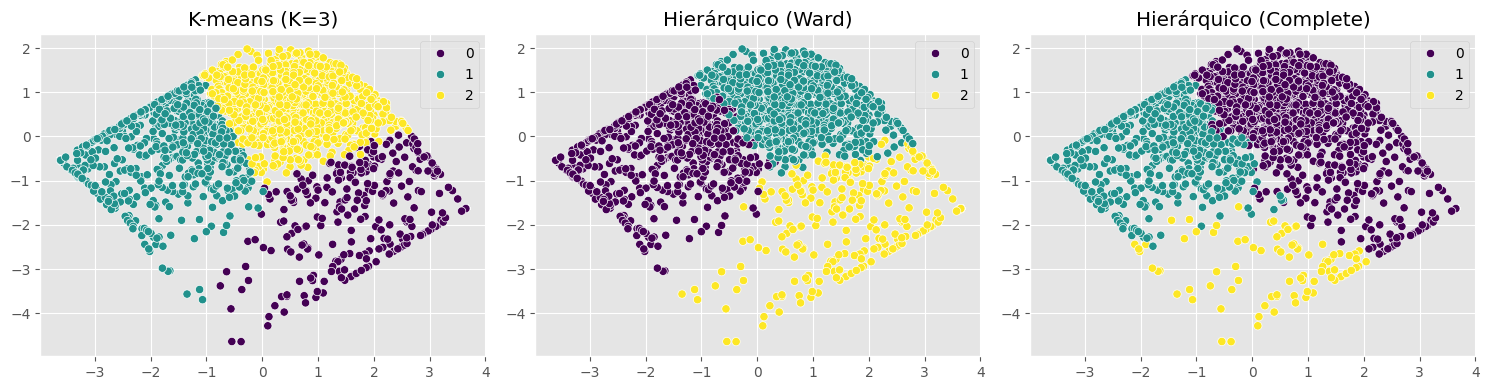

In [62]:
plt.figure(figsize=(15, 4))

# K-means
plt.subplot(1, 3, 1)
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=kmeans_labels, palette='viridis')
plt.title(f'K-means (K={optimal_k})')

# Hierárquico - Ward
plt.subplot(1, 3, 2)
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=hierarchical_labels['ward'], palette='viridis')
plt.title('Hierárquico (Ward)')

# Hierárquico - Complete
plt.subplot(1, 3, 3)
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=hierarchical_labels['complete'], palette='viridis')
plt.title('Hierárquico (Complete)')

plt.tight_layout()
plt.show()


In [63]:
if y is not None:
    y_numeric = y.str.replace('.', '').map({'BENIGN': 0, 'MALIGNANT': 1}).astype(int)

    for label_name, labels in [
        ('K-means', kmeans_labels),
        ('Hierárquico (Ward)', hierarchical_labels['ward']),
        ('Hierárquico (Complete)', hierarchical_labels['complete'])
    ]:
        print(f"\n{label_name} - Comparação com classes reais:")
        print(pd.crosstab(labels, y_numeric, rownames=['Cluster'], colnames=['Classe Real'], margins=True))



K-means - Comparação com classes reais:
Classe Real    0    1   All
Cluster                    
0            173  114   287
1            301  310   611
2            444  494   938
All          918  918  1836

Hierárquico (Ward) - Comparação com classes reais:
Classe Real    0    1   All
Cluster                    
0            318  338   656
1            431  477   908
2            169  103   272
All          918  918  1836

Hierárquico (Complete) - Comparação com classes reais:
Classe Real    0    1   All
Cluster                    
0            559  573  1132
1            303  316   619
2             56   29    85
All          918  918  1836


Escolhi o método de winsorização para tratar outliers porque é fácil de aplicar e não altera drasticamente os dados.
A padronização é essencial pro K-means e métodos baseados em distância funcionarem corretamente.
Usei o método do cotovelo para escolher o valor de K e parece que K=3 é um ponto estável na curva.
Comparei K-means com dois tipos de clustering hierárquico (Ward e Complete), que são bem diferentes no modo como formam os grupos.
As métricas Silhouette e Calinski-Harabasz foram escolhidas porque não precisam de rótulos (são próprias pra clustering) e avaliam bem a coesão e separação dos clusters.
No final, apesar de ser um problema não supervisionado, usei as classes originais pra ver se os clusters fazem algum sentido real (o que ajuda muito na interpretação dos padrões).


Com base nesses resultados, dá pra perceber que nenhum dos métodos separou perfeitamente as classes BENIGN e MALIGNANT.

K-means formou três clusters com proporções bem parecidas entre as classes. Isso mostra que os grupos criados até têm uma certa relação com os rótulos, mas não conseguiram distinguir claramente os dois tipos. Pode estar refletindo variações internas dos dados que não batem exatamente com o diagnóstico.

Hierárquico (Ward) foi um pouco melhor em isolar padrões: o cluster 2, por exemplo, tem muito mais casos da classe 0 (BENIGN) do que da 1, o que pode indicar um grupo mais “puro”. Mas ainda assim, os outros dois clusters estão bem mistos.

Hierárquico (Complete) criou um cluster pequeno (cluster 2) com pouquíssimas amostras, o que pode indicar que ele captou algum grupo mais “extremo” ou um ruído. Os outros dois clusters ficaram grandes e mistos também.